# Cobrar antes de perseguir

**Decisión:** ¿Cuánto riesgo captura un equipo que solo puede revisar el decil superior?

Notebook ejecutado sobre la muestra versionada del repositorio.

## 1. Contrato y calidad

Se comprueba la trazabilidad de la fuente, el tamaño de la muestra y las métricas finitas.

In [1]:
from pathlib import Path
from IPython.display import Image, display
from portfolio_analytics.common import project_root, read_json
root = project_root()
project = root / 'projects/04-payment-risk'
source = read_json(project / 'data/source.json')
display({'rows': source['rows'], 'source': source['url'], 'retrieved_at': source['retrieved_at']})

{'rows': 20000,
 'source': 'generated://portfolio_analytics.payment_risk.generate_invoices',
 'retrieved_at': '2026-07-30T05:07:22+00:00'}

## 2. Ejecución reproducible

La siguiente celda vuelve a correr la lógica compartida por el script y las pruebas.

In [2]:
from portfolio_analytics.payment_risk import analyze
metrics = analyze(project / 'data/sample.csv', project / 'outputs')
display(metrics)

{'train_invoices': 16074,
 'test_invoices': 3926,
 'test_start': '2025-05-26',
 'test_late_rate_pct': 31.33,
 'pr_auc': 0.586,
 'roc_auc': 0.739,
 'brier_score': 0.18,
 'top_decile_lift': 2.26,
 'late_amount_captured_top_decile_pct': 21.56}

## 3. Resultado visual

La figura se genera desde los mismos datos y queda versionada para revisión rápida.

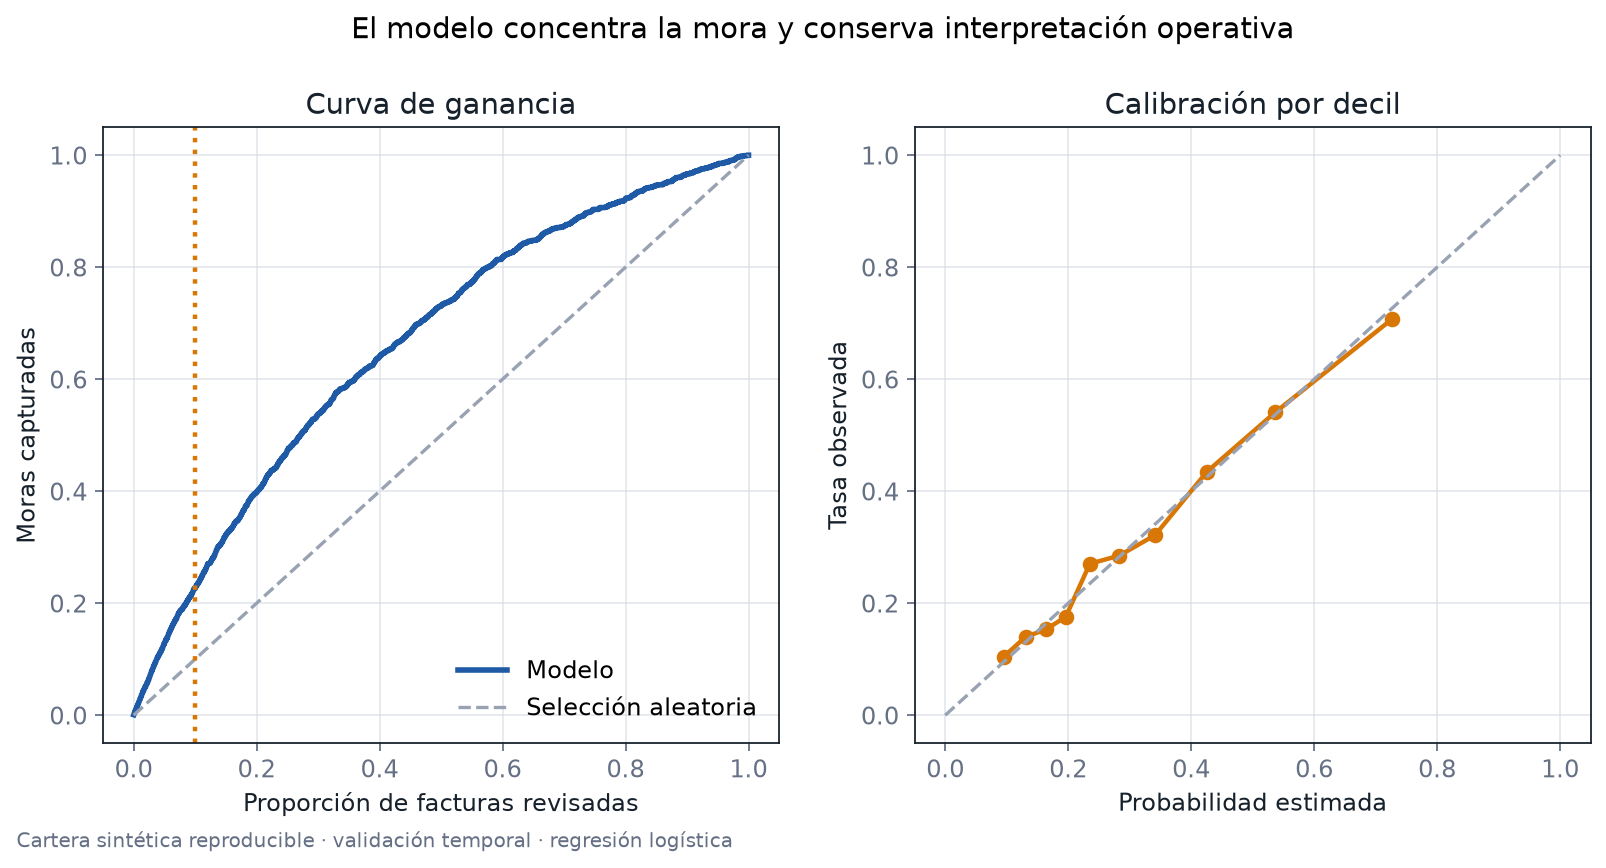

In [3]:
display(Image(filename=str(project / 'outputs/figure.png'), width=900))

## 4. Conclusión y límite

Un modelo simple crea valor cuando respeta el tiempo y se traduce a capacidad operativa.